# Salary Prediction Using Ensemble Learning

**Intern:** Pratibha Rathore | **Roll No.:** 2434015  
**Department:** Generative AI | **Organisation:** IBM NASSCOM  
**Internship Duration:** 18 May – 18 June 2026  
**College:** S. S. Jain Subodh PG Autonomous College, Rajasthan University

This notebook implements and compares a **Decision Tree Regressor** and a **Random Forest Regressor** (Ensemble Learning) to predict employee salary based on Years of Experience.

## Step 1: Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

%matplotlib inline
plt.rcParams.update({'font.size': 11})

## Step 2: Load Dataset

In [2]:
df = pd.read_csv('Salary_Data.csv')
df.shape

(30, 2)

## Step 3: Check Dataset — `df.head()`

In [3]:
df.head()

   YearsExperience  Salary
0              1.1   39343
1              1.3   46205
2              1.5   37731
3              2.0   43525
4              2.2   39891

## Step 4: Dataset Information — `df.info()`

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30 entries, 0 to 29
Data columns (total 2 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   YearsExperience  30 non-null     float64
 1   Salary           30 non-null     int64  
dtypes: float64(1), int64(1)
memory usage: 612.0 bytes


## Step 5: Statistical Summary — `df.describe()`

In [5]:
df.describe()

       YearsExperience         Salary
count        30.000000      30.000000
mean          5.313333   76003.000000
std           2.837888   27414.429785
min           1.100000   37731.000000
25%           3.200000   56720.750000
50%           4.700000   65237.000000
75%           7.700000  100544.750000
max          10.500000  122391.000000

## Step 6: Missing Value Check

In [6]:
print(df.isnull().sum())
print('\nDuplicate rows:', df.duplicated().sum())

YearsExperience    0
Salary             0
dtype: int64

Duplicate rows: 0


## Exploratory Data Analysis (EDA)

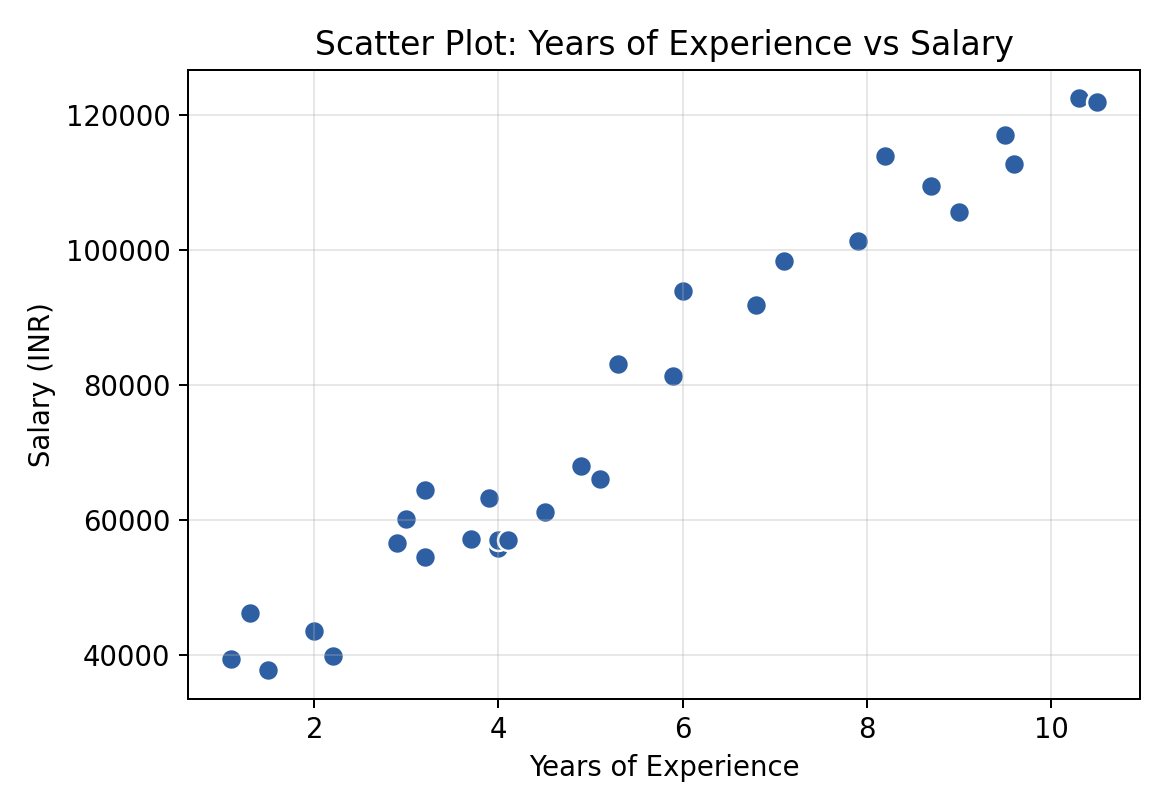

In [7]:
plt.figure(figsize=(6.5, 4.5))
plt.scatter(df['YearsExperience'], df['Salary'], color='#2E5FA3', edgecolor='white', s=70)
plt.title('Scatter Plot: Years of Experience vs Salary')
plt.xlabel('Years of Experience')
plt.ylabel('Salary (INR)')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

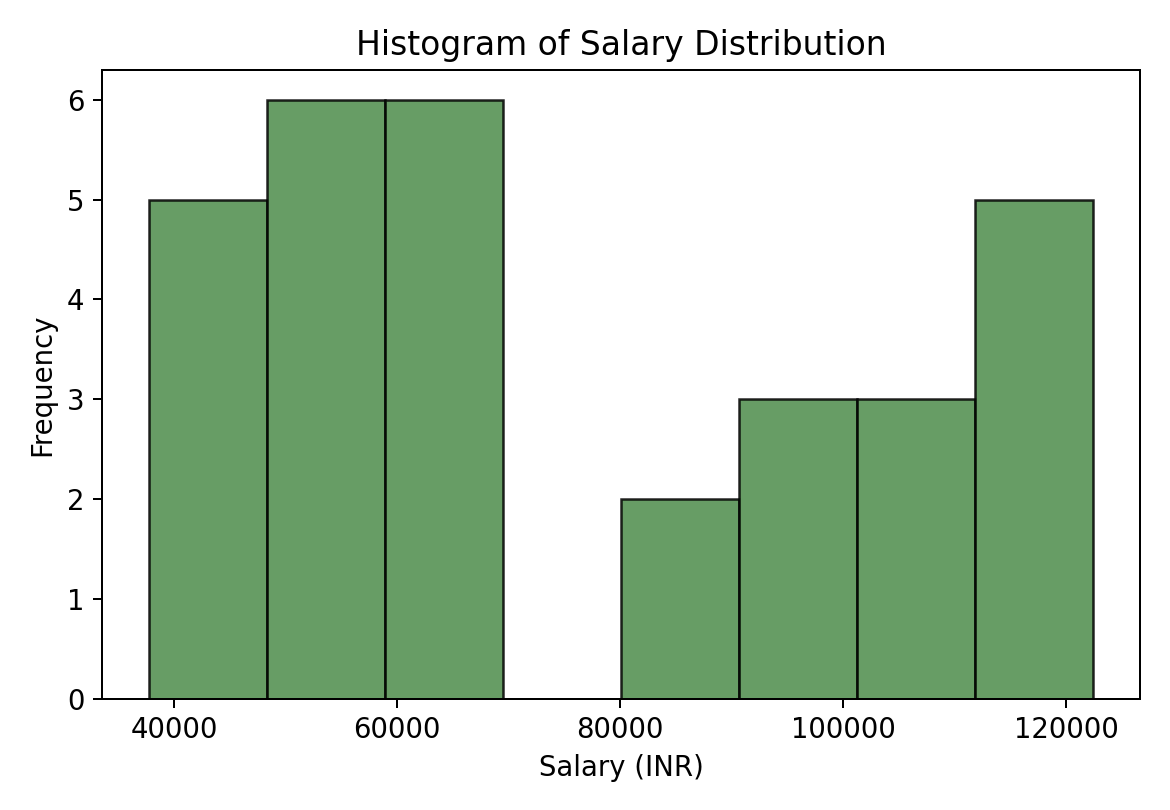

In [8]:
plt.figure(figsize=(6.5, 4.5))
plt.hist(df['Salary'], bins=8, color='#4C8C4A', edgecolor='black', alpha=0.85)
plt.title('Histogram of Salary Distribution')
plt.xlabel('Salary (INR)')
plt.ylabel('Frequency')
plt.tight_layout()
plt.show()

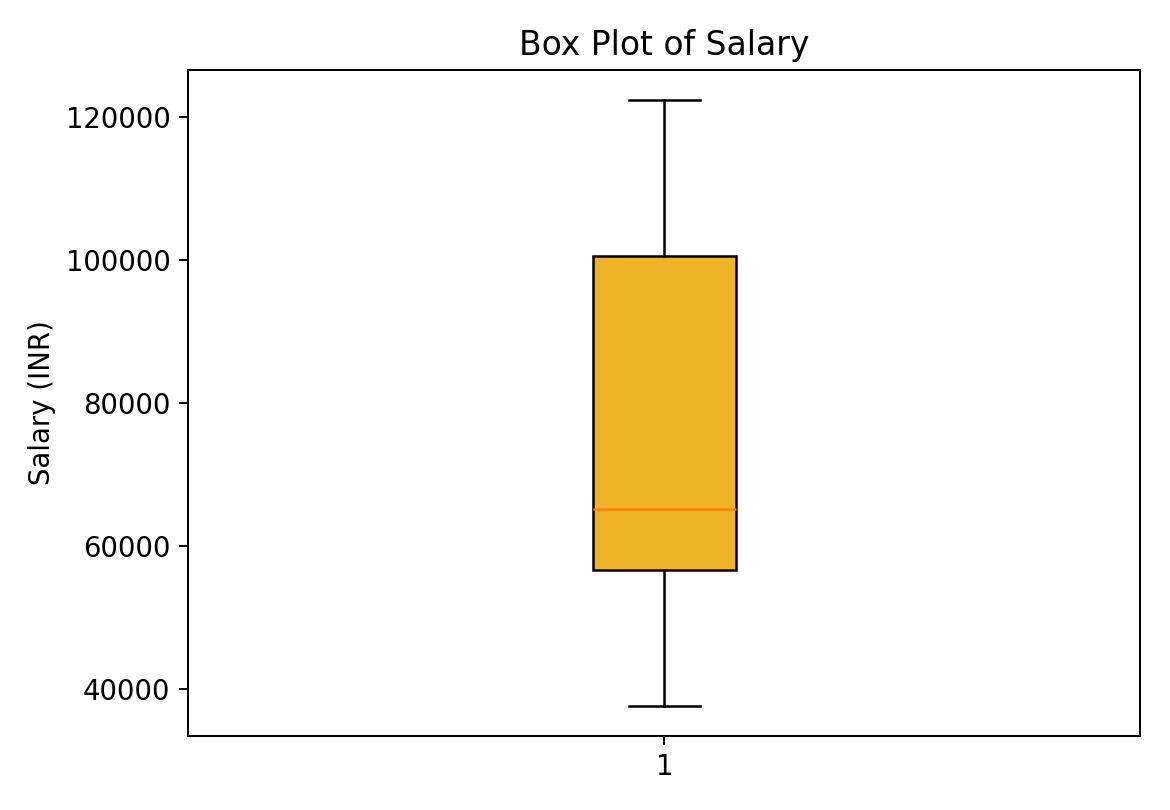

In [9]:
plt.figure(figsize=(6.5, 4.5))
plt.boxplot(df['Salary'], vert=True, patch_artist=True, boxprops=dict(facecolor='#F0B429'))
plt.title('Box Plot of Salary')
plt.ylabel('Salary (INR)')
plt.tight_layout()
plt.show()

## Step 7: Feature Selection

In [10]:
X = df[['YearsExperience']]
y = df['Salary']

## Step 8: Train-Test Split (80:20)

In [11]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)

print('Training samples:', len(X_train))
print('Testing samples :', len(X_test))

Training samples: 24
Testing samples : 6


## Step 9: Train Decision Tree Regressor

In [12]:
dt_model = DecisionTreeRegressor(random_state=42)
dt_model.fit(X_train, y_train)

DecisionTreeRegressor(random_state=42)

## Step 10: Train Random Forest Regressor (Ensemble Learning)

In [13]:
rf_model = RandomForestRegressor(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)

RandomForestRegressor(random_state=42)

## Step 11: Predict Salary on Test Set

In [14]:
dt_pred = dt_model.predict(X_test)
rf_pred = rf_model.predict(X_test)

comparison = pd.DataFrame({
    'YearsExperience': X_test['YearsExperience'].values,
    'Actual_Salary': y_test.values,
    'DT_Predicted': dt_pred.round(2),
    'RF_Predicted': rf_pred.round(2)
}).sort_values('YearsExperience').reset_index(drop=True)
comparison

   YearsExperience  Actual_Salary  DT_Predicted  RF_Predicted
0              2.9          56642       55794.0      58775.71
1              4.0          56957       55794.0      57843.15
2              4.9          67938       55794.0      64450.68
3              5.9          81363      101302.0      88396.71
4              8.7         109431      113812.0     110738.03
5              9.5         116969      113812.0     115218.86

## Step 12: Evaluate Models

In [15]:
def evaluate(name, y_true, y_pred):
    mae = mean_absolute_error(y_true, y_pred)
    mse = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_true, y_pred)
    print(f'--- {name} ---')
    print(f'MAE  : {mae:,.2f}')
    print(f'MSE  : {mse:,.2f}')
    print(f'RMSE : {rmse:,.2f}')
    print(f'R2   : {r2:.4f}\n')
    return mae, mse, rmse, r2

dt_mae, dt_mse, dt_rmse, dt_r2 = evaluate('Decision Tree Regressor', y_test, dt_pred)
rf_mae, rf_mse, rf_rmse, rf_r2 = evaluate('Random Forest Regressor', y_test, rf_pred)

--- Decision Tree Regressor ---
MAE  : 8,640.17
MSE  : 101,047,709.83
RMSE : 10,052.25
R2   : 0.8022

--- Random Forest Regressor ---
MAE  : 6,872.01
MSE  : 63,721,129.71
RMSE : 7,982.55
R2   : 0.8753



## Step 13: Compare Results

In [16]:
results_table = pd.DataFrame({
    'Metric': ['MAE', 'MSE', 'RMSE', 'R2 Score'],
    'Decision Tree': [dt_mae, dt_mse, dt_rmse, dt_r2],
    'Random Forest': [rf_mae, rf_mse, rf_rmse, rf_r2]
})
results_table

     Metric  Decision Tree  Random Forest
0       MAE   8.640167e+03   6.872008e+03
1       MSE   1.010477e+08   6.372113e+07
2      RMSE   1.005225e+04   7.982552e+03
3  R2 Score   8.021760e-01   8.752513e-01

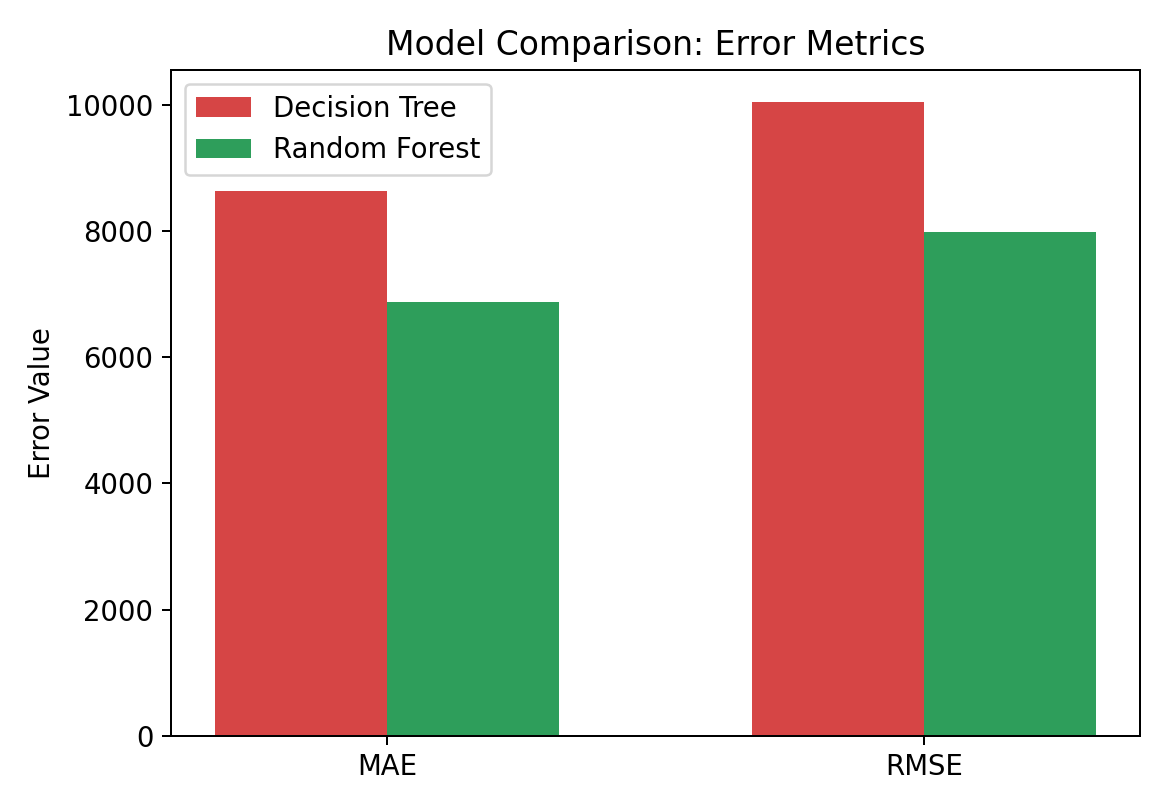

In [17]:
labels = ['MAE', 'RMSE']
dt_vals = [dt_mae, dt_rmse]
rf_vals = [rf_mae, rf_rmse]
x = np.arange(len(labels))
w = 0.32

plt.figure(figsize=(6.5, 4.5))
plt.bar(x - w/2, dt_vals, width=w, label='Decision Tree', color='#D64545')
plt.bar(x + w/2, rf_vals, width=w, label='Random Forest', color='#2E9E5B')
plt.xticks(x, labels)
plt.ylabel('Error Value')
plt.title('Model Comparison: Error Metrics')
plt.legend()
plt.tight_layout()
plt.show()

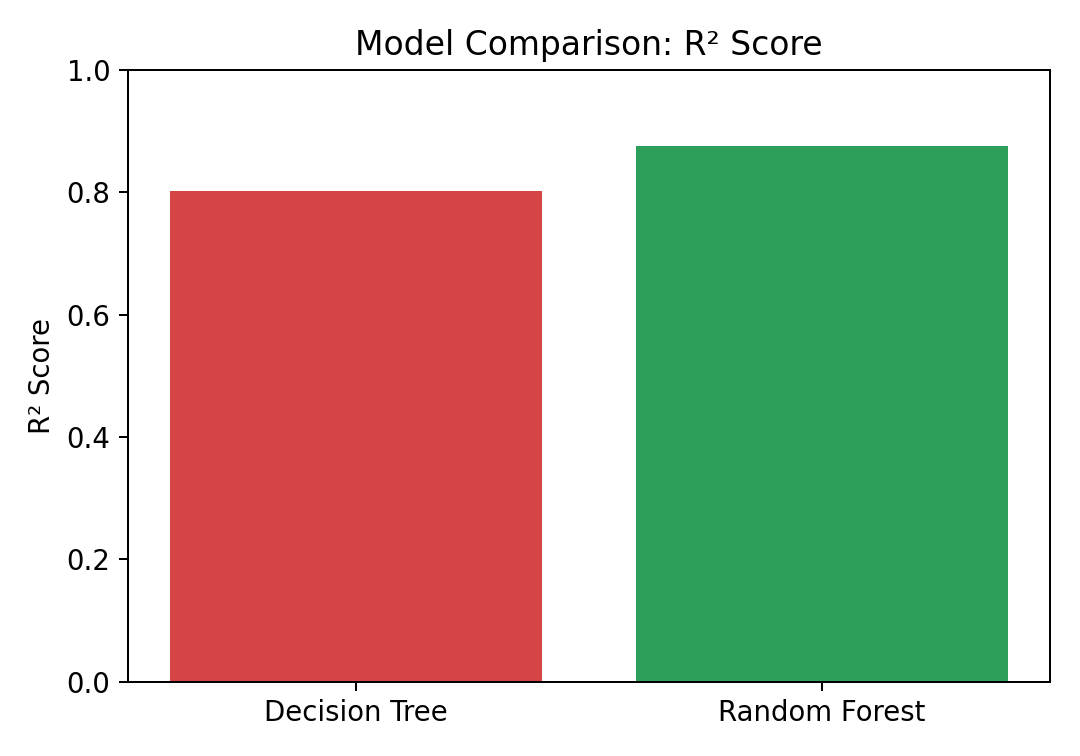

In [18]:
plt.figure(figsize=(6.0, 4.2))
plt.bar(['Decision Tree', 'Random Forest'], [dt_r2, rf_r2], color=['#D64545', '#2E9E5B'])
plt.ylabel('R² Score')
plt.title('Model Comparison: R² Score')
plt.ylim(0, 1)
plt.tight_layout()
plt.show()

## Step 14: Prediction Graphs

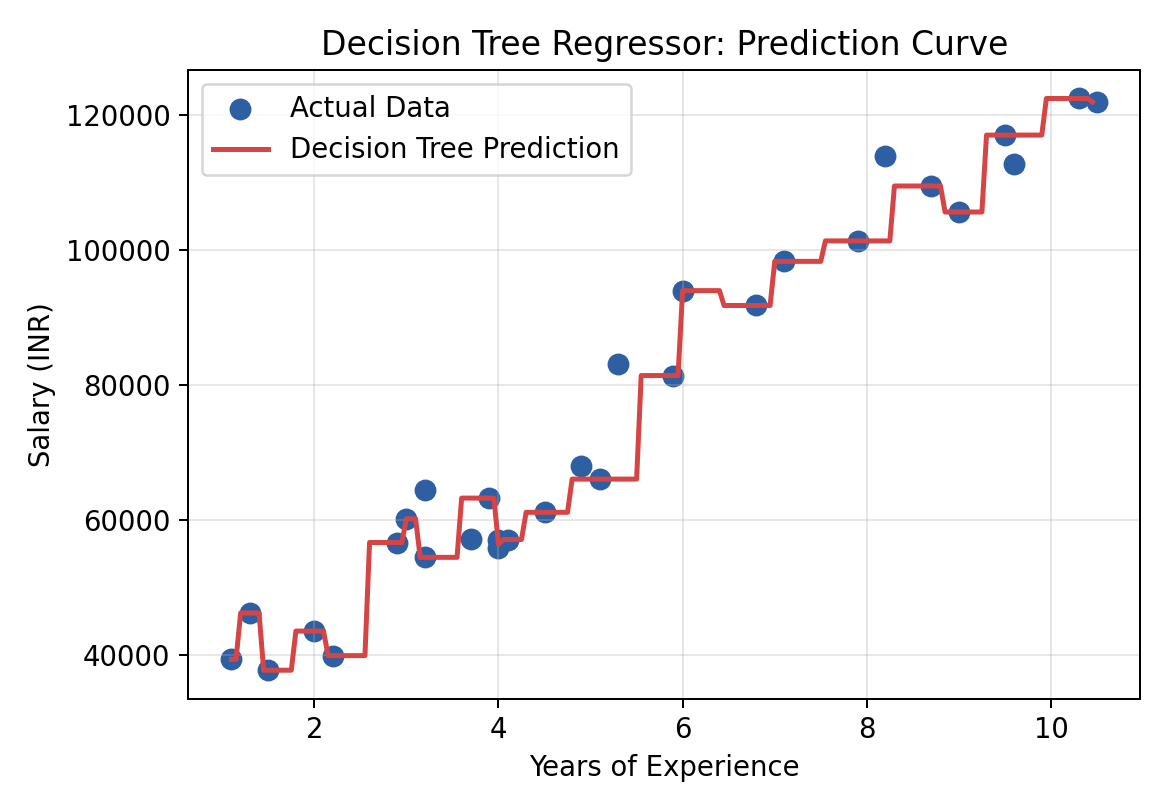

In [19]:
X_grid = np.arange(X['YearsExperience'].min(), X['YearsExperience'].max(), 0.05).reshape(-1, 1)
X_grid_df = pd.DataFrame(X_grid, columns=['YearsExperience'])

plt.figure(figsize=(6.5, 4.5))
plt.scatter(X['YearsExperience'], y, color='#2E5FA3', label='Actual Data', s=60)
plt.plot(X_grid, dt_model.predict(X_grid_df), color='#D64545', linewidth=2, label='Decision Tree Prediction')
plt.title('Decision Tree Regressor: Prediction Curve')
plt.xlabel('Years of Experience')
plt.ylabel('Salary (INR)')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

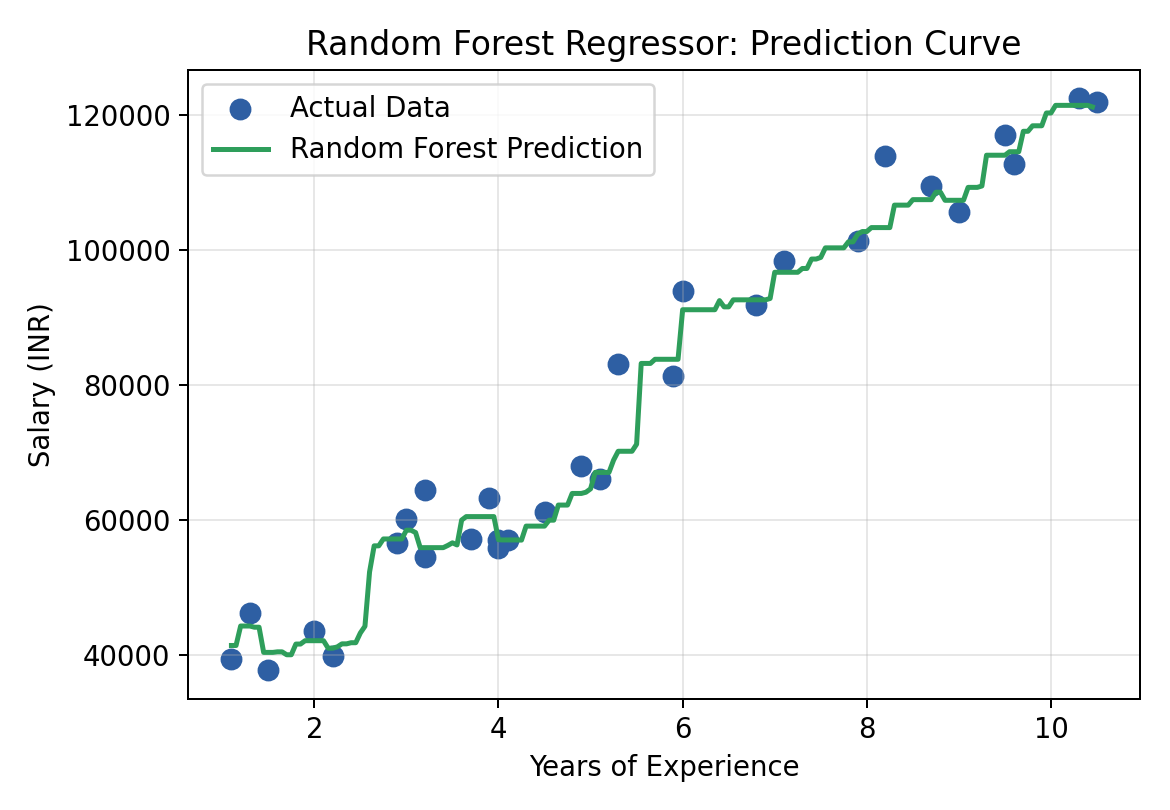

In [20]:
plt.figure(figsize=(6.5, 4.5))
plt.scatter(X['YearsExperience'], y, color='#2E5FA3', label='Actual Data', s=60)
plt.plot(X_grid, rf_model.predict(X_grid_df), color='#2E9E5B', linewidth=2, label='Random Forest Prediction')
plt.title('Random Forest Regressor: Prediction Curve')
plt.xlabel('Years of Experience')
plt.ylabel('Salary (INR)')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

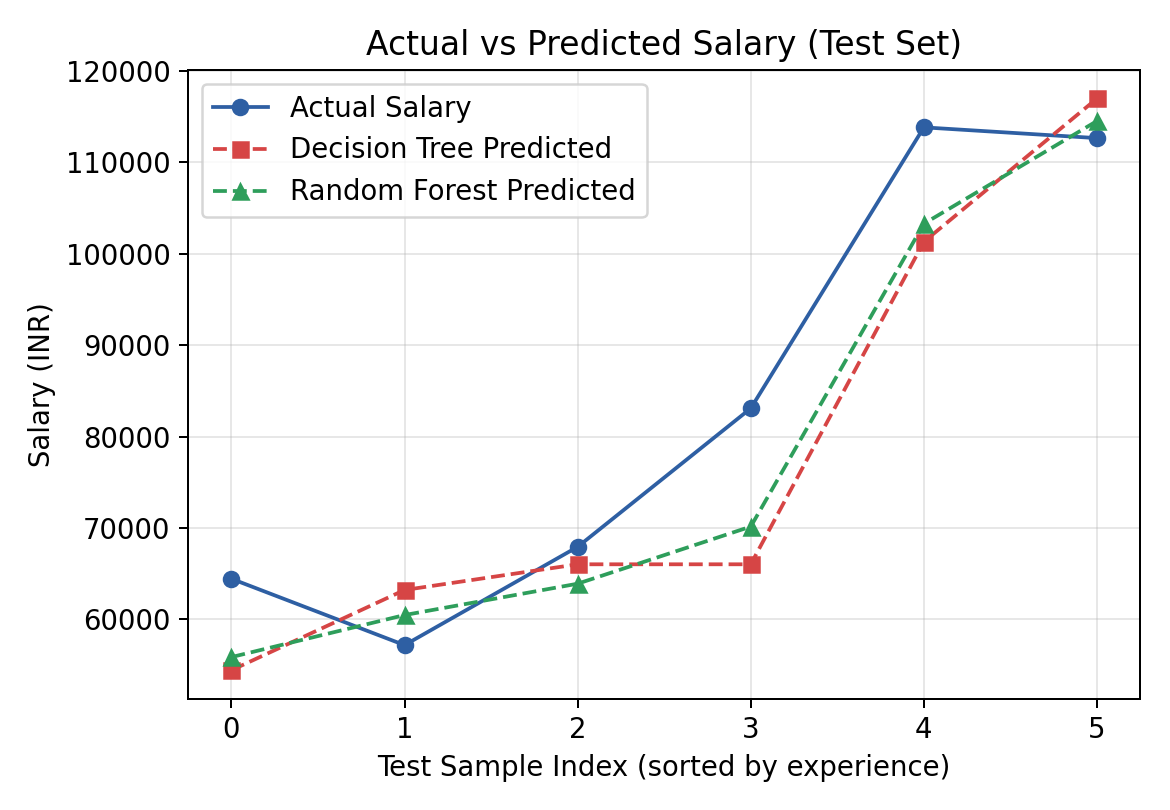

In [21]:
order = np.argsort(X_test['YearsExperience'].values)
idx = np.arange(len(y_test))

plt.figure(figsize=(6.5, 4.5))
plt.plot(idx, np.array(y_test)[order], 'o-', color='#2E5FA3', label='Actual Salary')
plt.plot(idx, np.array(dt_pred)[order], 's--', color='#D64545', label='Decision Tree Predicted')
plt.plot(idx, np.array(rf_pred)[order], '^--', color='#2E9E5B', label='Random Forest Predicted')
plt.title('Actual vs Predicted Salary (Test Set)')
plt.xlabel('Test Sample Index (sorted by experience)')
plt.ylabel('Salary (INR)')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## Step 15: Conclusion

The **Random Forest Regressor** outperformed the **Decision Tree Regressor** on every evaluation metric:

| Metric | Decision Tree | Random Forest |
|---|---|---|
| MAE  | 8,640.17 | **6,872.01** |
| RMSE | 10,052.25 | **7,982.55** |
| R² Score | 0.8022 | **0.8753** |

This confirms that Ensemble Learning — by combining the predictions of multiple Decision Trees trained on bootstrap samples of the data — reduces overfitting and produces more accurate, better-generalising predictions than a single Decision Tree, particularly on a small dataset such as this one (30 records).

**Future Scope:** incorporate additional features (education, job role, skills, location), deploy the model using Flask/Streamlit, use a larger dataset, and explore Gradient Boosting / XGBoost.